# M2 Notebook 01 — Supervised Learning Foundations

**SRAI Book 2 | Chapter 1 | PU-B02-C01**

**Status:** Executed controlled review candidate v0.3

This canonical laboratory follows the SRAI evidence chain: decision, population, prediction time, data, representation, split, baseline, model, checks, generalization evidence, interpretation and action.


## Learning objectives

1. Freeze a prediction design before modeling.
2. Keep preprocessing inside pipelines.
3. Compare learned models with baselines on untouched data.
4. diagnose underfitting, overfitting, leakage, uncertainty, and subgroup variation.
5. Produce a reproducible evidence table.


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    log_loss, confusion_matrix, precision_recall_curve)
from sklearn.model_selection import learning_curve, TimeSeriesSplit, cross_val_score
SEED=42
rng=np.random.default_rng(SEED)
print({"python":sys.version.split()[0],"platform":platform.platform(),"seed":SEED})


{'python': '3.12.14', 'platform': 'Linux-6.18.35-x86_64-with-glibc2.39', 'seed': 42}


## 1 Prediction design

**Unit:** facility-month. **Issue time:** end of month t. **Target:** visits in t+1. **Action:** allocate temporary staff. Features must be available and finalized at issue time.


In [2]:
n_facilities=24
months=pd.date_range("2019-01-01", periods=72, freq="MS")
rows=[]
regions=np.array(["North","Central","South","East"]*6)
for fid in range(n_facilities):
    base=rng.uniform(120,420); trend=rng.uniform(-0.3,1.2); region=regions[fid]
    population=rng.integers(12000,65000)
    for t,date in enumerate(months):
        seasonal=35*np.sin(2*np.pi*t/12)+18*np.cos(2*np.pi*t/6)
        closure=int(date.month in [8,12] and rng.random()<.18)
        staffing=8+0.018*base+rng.normal(0,1.2)
        visits=base+trend*t+seasonal+0.0018*population-32*closure+7*staffing+rng.normal(0,24)
        rows.append([fid,region,date,population,closure,staffing,max(20,visits)])
df=pd.DataFrame(rows,columns=["facility","region","date","population","planned_closure","staffing","visits"])
df=df.sort_values(["facility","date"])
df["lag_1"]=df.groupby("facility")["visits"].shift(1)
df["lag_12"]=df.groupby("facility")["visits"].shift(12)
df["month"]=df["date"].dt.month.astype(str)
df=df.dropna().reset_index(drop=True)
print(df.shape); df.head()


   facility region       date  ...       lag_1      lag_12  month
0         0  North 2020-01-01  ...  523.887360  494.546452      1
1         0  North 2020-02-01  ...  592.788804  534.458733      2
2         0  North 2020-03-01  ...  530.920971  534.438412      3
3         0  North 2020-04-01  ...  549.745705  547.485489      4
4         0  North 2020-05-01  ...  544.593946  546.332902      5

[5 rows x 10 columns]

(1440, 10)


In [3]:
summary=df[["visits","lag_1","lag_12","population","staffing"]].describe().T
summary[["mean","std","min","max"]].round(2)


                mean       std       min       max
visits        443.13    102.25    159.81    675.19
lag_1         442.56    102.36    159.81    675.19
lag_12        437.05    102.10    159.81    660.29
population  33728.96  14372.17  12999.00  59834.00
staffing       12.99      1.90      7.98     18.58

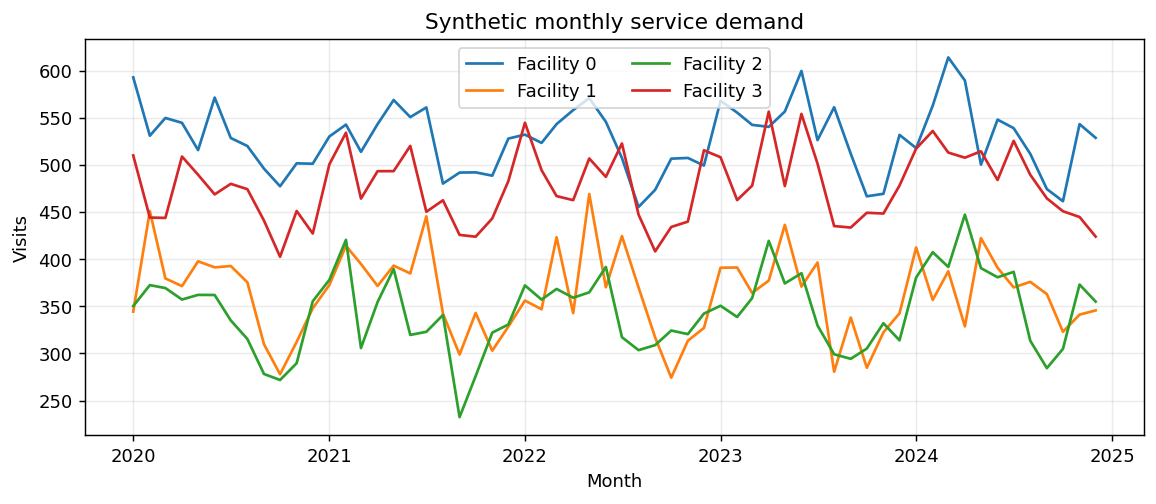

In [4]:
fig,ax=plt.subplots(figsize=(9,4))
for fid in range(4):
    g=df[df.facility==fid]
    ax.plot(g.date,g.visits,label=f"Facility {fid}")
ax.set(title="Synthetic monthly service demand",ylabel="Visits",xlabel="Month")
ax.legend(ncol=2); ax.grid(alpha=.25); plt.tight_layout(); plt.show()


## 2 Frozen temporal split

Random row splitting would mix future months and closely related facility records into training. We reserve the latest 12 months for final testing and the preceding 12 for validation.


In [5]:
train_end=pd.Timestamp("2022-12-01")
valid_end=pd.Timestamp("2023-12-01")
split=np.select([df.date<=train_end,df.date<=valid_end],["train","validation"],default="test")
df["split"]=split
df.groupby("split").agg(rows=("visits","size"),start=("date","min"),end=("date","max"))


            rows      start        end
split                                 
test         288 2024-01-01 2024-12-01
train        864 2020-01-01 2022-12-01
validation   288 2023-01-01 2023-12-01

In [6]:
features_num=["lag_1","lag_12","population","staffing","planned_closure"]
features_cat=["region","month"]
target="visits"
train=df[df.split=="train"]; valid=df[df.split=="validation"]; test=df[df.split=="test"]
X_train,y_train=train[features_num+features_cat],train[target]
X_valid,y_valid=valid[features_num+features_cat],valid[target]
X_test,y_test=test[features_num+features_cat],test[target]
print(X_train.shape,X_valid.shape,X_test.shape)


(864, 7) (288, 7) (288, 7)


## 3 Baselines

The training mean tests whether the pipeline adds signal. The seasonal-naive forecast uses demand from the same month one year earlier and is operationally credible.


In [7]:
pred_mean=np.repeat(y_train.mean(),len(test))
pred_seasonal=test["lag_12"].to_numpy()
def reg_metrics(y,p):
    return {"MAE":mean_absolute_error(y,p),"RMSE":mean_squared_error(y,p)**0.5,"R2":r2_score(y,p)}
pd.DataFrame({"Training mean":reg_metrics(y_test,pred_mean),"Seasonal naive":reg_metrics(y_test,pred_seasonal)}).T.round(3)


                   MAE     RMSE     R2
Training mean   88.880  103.958 -0.037
Seasonal naive  31.426   40.496  0.843

## 4 Leakage-safe regression pipeline

All learned transformations are fitted on training data within the pipeline. Validation selects the regularization strength; test data remain untouched.


In [8]:
num_pipe=Pipeline([("impute",SimpleImputer(strategy="median")),("scale",StandardScaler())])
cat_pipe=Pipeline([("impute",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore"))])
prep=ColumnTransformer([("num",num_pipe,features_num),("cat",cat_pipe,features_cat)])
rows=[]
models={}
for alpha in [0.0,0.1,1.0,10.0,100.0]:
    estimator=LinearRegression() if alpha==0 else Ridge(alpha=alpha)
    pipe=Pipeline([("prep",clone(prep)),("model",estimator)])
    pipe.fit(X_train,y_train); pv=pipe.predict(X_valid)
    rows.append({"alpha":alpha,**reg_metrics(y_valid,pv)})
    models[alpha]=pipe
validation_results=pd.DataFrame(rows).sort_values("RMSE")
validation_results.round(3)


   alpha     MAE    RMSE     R2
2    1.0  23.911  30.471  0.914
1    0.1  23.913  30.472  0.914
0    0.0  23.913  30.472  0.914
3   10.0  23.926  30.490  0.914
4  100.0  24.741  31.455  0.908

In [9]:
best_alpha=float(validation_results.iloc[0]["alpha"])
best_model=models[best_alpha]
test_pred=best_model.predict(X_test)
comparison=pd.DataFrame({
 "Training mean":reg_metrics(y_test,pred_mean),
 "Seasonal naive":reg_metrics(y_test,pred_seasonal),
 f"Ridge alpha={best_alpha:g}":reg_metrics(y_test,test_pred)}).T
comparison.round(3)


                   MAE     RMSE     R2
Training mean   88.880  103.958 -0.037
Seasonal naive  31.426   40.496  0.843
Ridge alpha=1   24.728   30.876  0.909

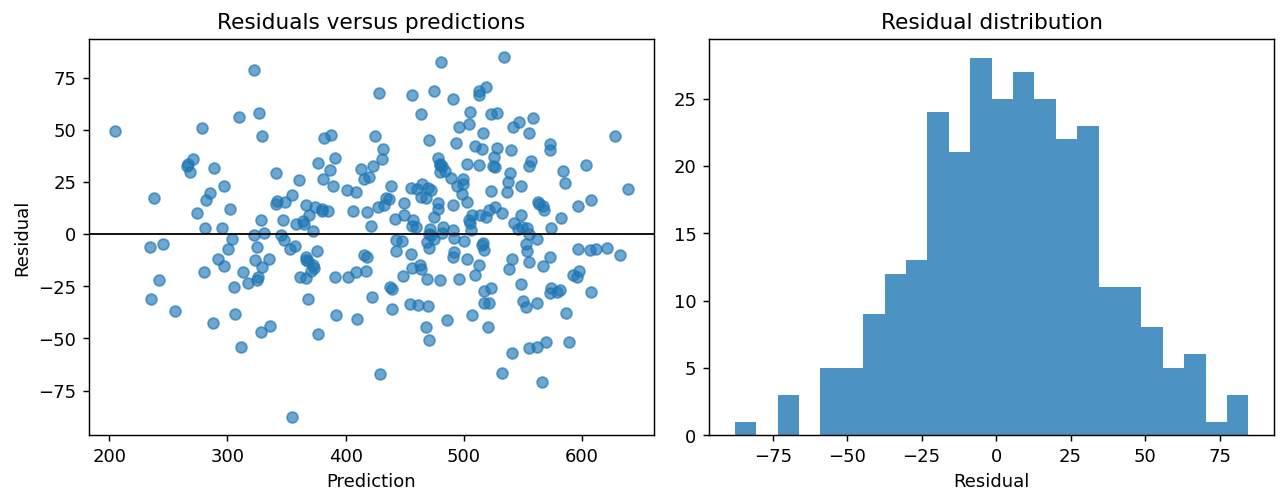

In [10]:
residual=y_test.to_numpy()-test_pred
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(test_pred,residual,alpha=.65); ax[0].axhline(0,color="black",lw=1)
ax[0].set(xlabel="Prediction",ylabel="Residual",title="Residuals versus predictions")
ax[1].hist(residual,bins=24,color="#1f77b4",alpha=.8); ax[1].set(title="Residual distribution",xlabel="Residual")
plt.tight_layout(); plt.show()


## 5 Learning curves

The curve compares polynomial capacity while respecting temporal order through time-series cross-validation.


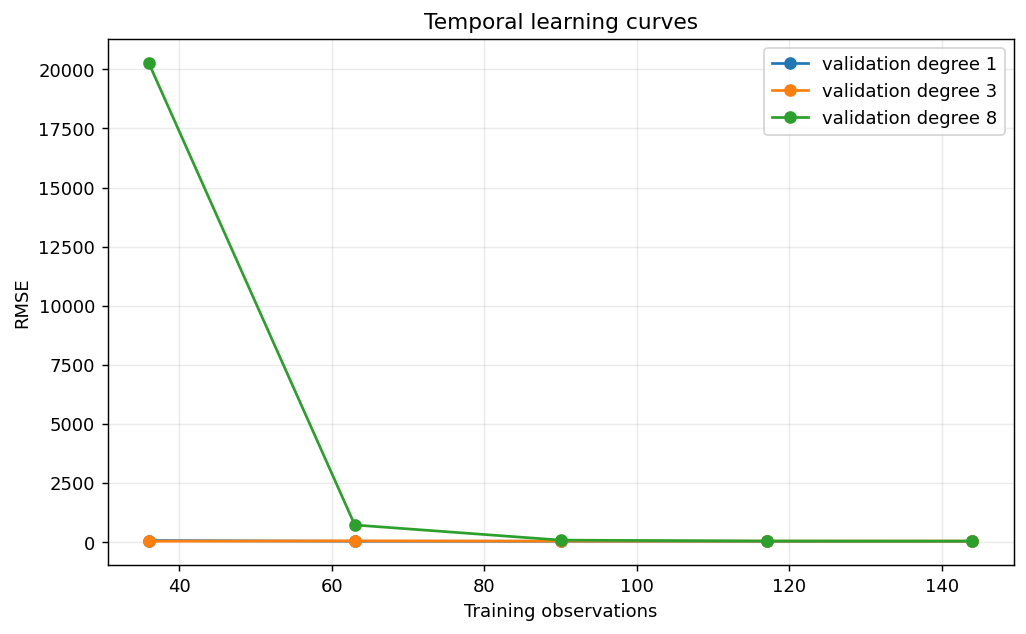

In [11]:
simple_X=train[["lag_12"]].to_numpy(); simple_y=y_train.to_numpy()
fig,ax=plt.subplots(figsize=(8,5))
cv=TimeSeriesSplit(n_splits=5)
for degree in [1,3,8]:
    model=Pipeline([("poly",PolynomialFeatures(degree,include_bias=False)),("ridge",Ridge(alpha=1.0))])
    sizes,tr,va=learning_curve(model,simple_X,simple_y,cv=cv,scoring="neg_root_mean_squared_error",train_sizes=np.linspace(.25,1,5))
    ax.plot(sizes,-va.mean(axis=1),marker="o",label=f"validation degree {degree}")
ax.set(xlabel="Training observations",ylabel="RMSE",title="Temporal learning curves")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()


## 6 Leakage demonstration

A post-outcome variable derived from the current target produces implausibly strong results. This is target leakage, not genuine predictive information.


In [12]:
leak_df=df.copy(); leak_df["resolved_count"]=leak_df["visits"]+rng.normal(0,2,len(leak_df))
leak_train=leak_df[leak_df.split=="train"]; leak_test=leak_df[leak_df.split=="test"]
leak_model=LinearRegression().fit(leak_train[["lag_12","resolved_count"]],leak_train.visits)
leak_pred=leak_model.predict(leak_test[["lag_12","resolved_count"]])
pd.DataFrame({"Valid seasonal baseline":reg_metrics(y_test,pred_seasonal),"Invalid leaked model":reg_metrics(leak_test.visits,leak_pred)}).T.round(3)


                            MAE    RMSE     R2
Valid seasonal baseline  31.426  40.496  0.843
Invalid leaked model      1.650   2.048  1.000

## 7 Classification framing and threshold selection

We define high demand using a threshold fixed from training data. Validation data select an operating threshold; test data evaluate it once.


In [13]:
high_cut=float(y_train.quantile(.75))
yc_train=(y_train>=high_cut).astype(int); yc_valid=(y_valid>=high_cut).astype(int); yc_test=(y_test>=high_cut).astype(int)
clf=Pipeline([("prep",clone(prep)),("model",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=SEED))])
clf.fit(X_train,yc_train)
pv=clf.predict_proba(X_valid)[:,1]
thresholds=np.linspace(.15,.85,29)
threshold_table=[]
for t in thresholds:
    pr=(pv>=t).astype(int)
    threshold_table.append({"threshold":t,"precision":precision_score(yc_valid,pr,zero_division=0),"recall":recall_score(yc_valid,pr),"f1":f1_score(yc_valid,pr)})
threshold_table=pd.DataFrame(threshold_table)
threshold_table.sort_values("f1",ascending=False).head().round(3)


    threshold  precision  recall     f1
19      0.625      0.809   0.867  0.837
20      0.650      0.824   0.843  0.833
18      0.600      0.800   0.867  0.832
17      0.575      0.777   0.880  0.825
21      0.675      0.829   0.819  0.824

In [14]:
chosen_t=float(threshold_table.sort_values("f1",ascending=False).iloc[0].threshold)
pt=clf.predict_proba(X_test)[:,1]; yt_hat=(pt>=chosen_t).astype(int)
class_results=pd.Series({"threshold":chosen_t,"prevalence":yc_test.mean(),"accuracy":accuracy_score(yc_test,yt_hat),"precision":precision_score(yc_test,yt_hat),"recall":recall_score(yc_test,yt_hat),"f1":f1_score(yc_test,yt_hat),"roc_auc":roc_auc_score(yc_test,pt),"log_loss":log_loss(yc_test,pt)})
class_results.round(3)


threshold     0.625
prevalence    0.302
accuracy      0.889
precision     0.802
recall        0.839
f1            0.820
roc_auc       0.955
log_loss      0.275
dtype: float64

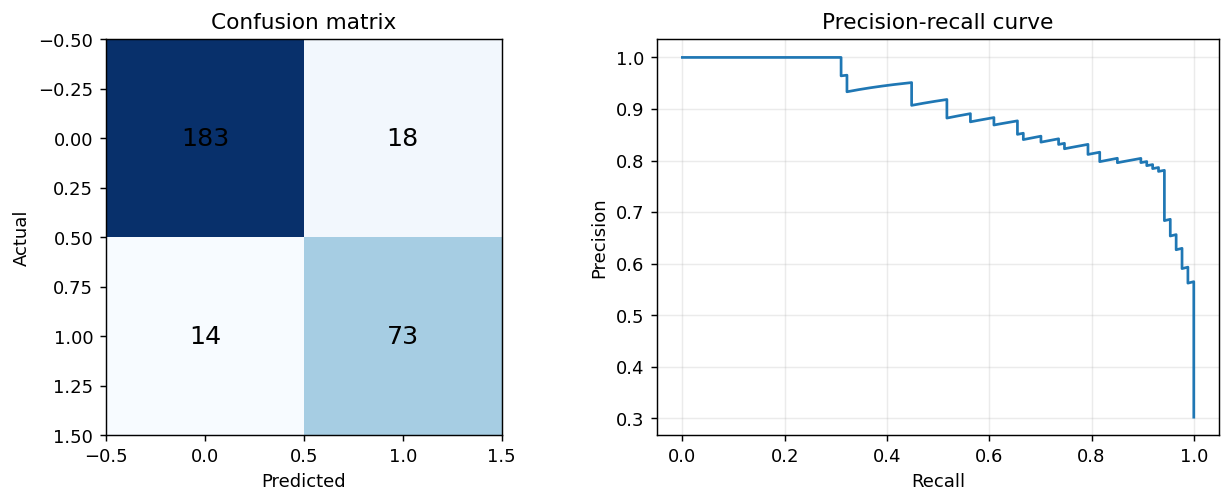

In [15]:
cm=confusion_matrix(yc_test,yt_hat)
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].imshow(cm,cmap="Blues"); ax[0].set(title="Confusion matrix",xlabel="Predicted",ylabel="Actual")
for i in range(2):
 for j in range(2): ax[0].text(j,i,cm[i,j],ha="center",va="center",fontsize=14)
precision,recall,thr=precision_recall_curve(yc_test,pt)
ax[1].plot(recall,precision); ax[1].set(xlabel="Recall",ylabel="Precision",title="Precision-recall curve"); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()


## 8 Bootstrap uncertainty

We resample test rows and calculate the paired MAE difference between the learned model and seasonal baseline.


In [16]:
diffs=[]
yarr=y_test.to_numpy()
for _ in range(1000):
    idx=rng.integers(0,len(yarr),len(yarr))
    diffs.append(mean_absolute_error(yarr[idx],pred_seasonal[idx])-mean_absolute_error(yarr[idx],test_pred[idx]))
ci=np.percentile(diffs,[2.5,50,97.5])
{"MAE improvement lower":round(ci[0],3),"median":round(ci[1],3),"upper":round(ci[2],3),"P(improvement>0)":round(float(np.mean(np.array(diffs)>0)),3)}


{'MAE improvement lower': np.float64(4.288), 'median': np.float64(6.657), 'upper': np.float64(9.053), 'P(improvement>0)': 1.0}

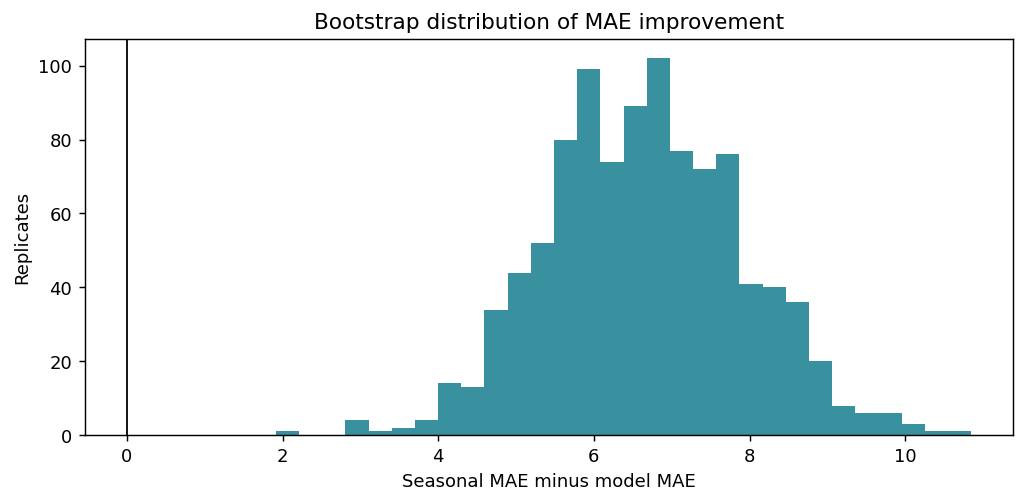

In [17]:
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(diffs,bins=30,color="#167d8d",alpha=.85); ax.axvline(0,color="black",lw=1)
ax.set(title="Bootstrap distribution of MAE improvement",xlabel="Seasonal MAE minus model MAE",ylabel="Replicates"); plt.tight_layout(); plt.show()


## 9 Subgroup performance

Regional results are diagnostic. Differences should trigger investigation of sample size, measurement, distribution, and service context.


In [18]:
audit=test[["region","visits"]].copy(); audit["prediction"]=test_pred; audit["abs_error"]=(audit.visits-audit.prediction).abs()
subgroup=audit.groupby("region").agg(n=("visits","size"),MAE=("abs_error","mean"),mean_actual=("visits","mean"),mean_prediction=("prediction","mean"))
subgroup.round(2)


          n    MAE  mean_actual  mean_prediction
region                                          
Central  72  22.53       448.60           443.96
East     72  25.67       458.87           449.25
North    72  23.56       420.02           418.16
South    72  27.16       500.57           495.66

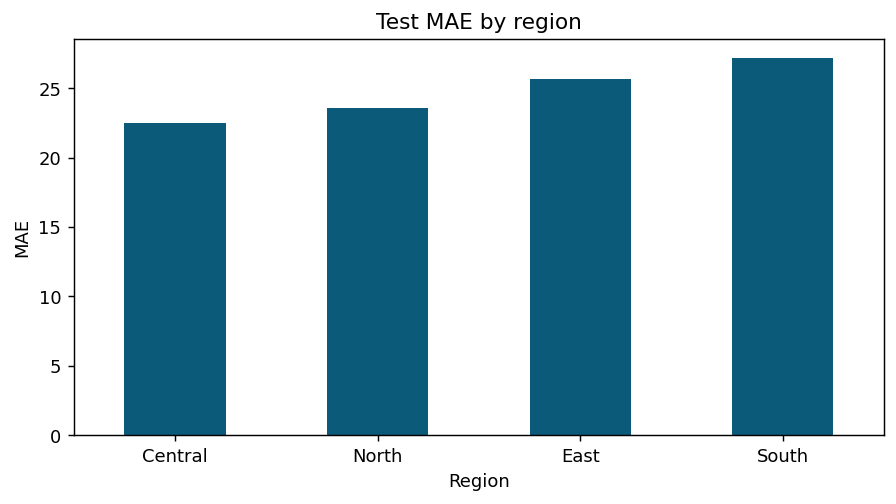

In [19]:
fig,ax=plt.subplots(figsize=(7,4)); subgroup.MAE.sort_values().plot(kind="bar",ax=ax,color="#0b5a7a")
ax.set(title="Test MAE by region",ylabel="MAE",xlabel="Region"); ax.tick_params(axis="x",rotation=0); plt.tight_layout(); plt.show()


## 10 Controlled evidence summary

A release record separates validated evidence from interpretation and remaining limitations.


In [20]:
evidence=pd.DataFrame([
 {"evidence":"Temporal split frozen","status":"PASS","detail":f"Train through {train_end.date()}, validation through {valid_end.date()}"},
 {"evidence":"Baseline comparison","status":"PASS","detail":f"Model test RMSE {comparison.iloc[-1].RMSE:.2f}"},
 {"evidence":"Leakage demonstration","status":"PASS","detail":"Post-outcome feature identified as invalid"},
 {"evidence":"Classification evaluation","status":"PASS","detail":f"Test ROC AUC {class_results.roc_auc:.3f}"},
 {"evidence":"Bootstrap uncertainty","status":"PASS","detail":f"95% CI improvement [{ci[0]:.2f}, {ci[2]:.2f}]"},
 {"evidence":"Subgroup audit","status":"REVIEW","detail":"Regional differences require contextual review"},
])
evidence


                    evidence  ...                                             detail
0      Temporal split frozen  ...  Train through 2022-12-01, validation through 2...
1        Baseline comparison  ...                              Model test RMSE 30.88
2      Leakage demonstration  ...         Post-outcome feature identified as invalid
3  Classification evaluation  ...                                 Test ROC AUC 0.955
4      Bootstrap uncertainty  ...                    95% CI improvement [4.29, 9.05]
5             Subgroup audit  ...     Regional differences require contextual review

[6 rows x 3 columns]

## Exercises

1. Replace the temporal split with a random row split and explain why the estimate changes.
2. Increase the noise and regenerate the learning curves.
3. Fit preprocessing to the full dataset before splitting; identify the contamination.
4. Select a threshold subject to a fixed review capacity rather than maximum F1.
5. Bootstrap by facility instead of by row and compare interval width.
6. Add a model-card cell documenting intended and excluded uses.


## Key conclusion

Supervised learning is a controlled evidence process. Generalization depends on problem formulation, prediction-time information, representative evaluation, leakage prevention, baselines, uncertainty, subgroup review, reproducibility, and governance—not on training fit alone.


## Canonical verification gate

The following assertions bind the notebook to the numeric facts published in the chapter.


In [21]:
# Canonical controlled-output verification
assert len(df) == 1440
assert len(train) == 864 and len(valid) == 288 and len(test) == 288
assert best_alpha == 1.0
assert abs(comparison.loc["Ridge alpha=1", "RMSE"] - 30.876) < 0.01
assert abs(class_results["roc_auc"] - 0.955) < 0.01
assert abs(chosen_t - 0.625) < 1e-12
assert reg_metrics(leak_test.visits, leak_pred)["RMSE"] < 3
print("CANONICAL VERIFICATION: PASS")
print({"rows": len(df), "test_RMSE": round(comparison.loc["Ridge alpha=1", "RMSE"], 3),
       "classification_ROC_AUC": round(class_results["roc_auc"], 3),
       "threshold": chosen_t, "seed": SEED})


CANONICAL VERIFICATION: PASS
{'rows': 1440, 'test_RMSE': 30.876, 'classification_ROC_AUC': 0.955, 'threshold': 0.625, 'seed': 42}
